In [95]:
import torch.nn as nn
import torch
import pandas as pd
# añadidos
from sklearn.preprocessing import StandardScaler
import numpy as np
import torch.utils.data as torch_data
import torch.optim as optim
from models import MLP_Simple, MLP_Medium, MLP_Deep
from tqdm import tqdm

In [59]:
data = pd.read_csv("Pokemon.csv")
data.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## Descripción de la tarea

Trabajaremos con un dataset de la serie "Pokémon" que desglosa las capacidades de cada criatura en atributos cuantitativos. La tarea consiste en utilizar arquitecturas de redes neuronales simples (MLP) para identificar patrones que distingan a los Pokémon Legendarios del resto. Deberán procesar estas variables y entrenar un clasificador que maximice la capacidad predictiva sobre la variable objetivo "Legendary".

Consideraciones:
- Debe entregarlo a más tardar el 29 de mayo a las 18:00 horas.
- Debe ser entregado al correo luis.llanca@uach.cl con el asunto "Tarea-1-MLP", el archivo debe llamarse NG-MLP-Tarea1.ipynb donde NG es el número de grupo. Es importante que el asunto sea exactamente el mismo. También, se les pedirá que se anoten en la plantilla (que se compartirá posteriormente) para una pequeña interrogación.
- Por cada 20 minutos de retraso, se descontará una décima de la nota. 
- Si necesitan ayuda, pueden escribir a los correos luis.llanca@uach.cl, luis.llanca@cenia.cl o escribir al discord de usuario: llanking (tengo una foto de mi gata). PD: prefiero mucho más el discord. 

### Explicación del dataset
Explique el dataset en detalle, incluyendo como mínimo una pequeña descripción de cada columna, el tipo de datos que contiene cada columna, y cualquier información adicional relevante para entender el dataset.

In [11]:
# Se usaron los siguientes métodos para analizar el dataset jeje
# data.info()
# data.describe()
# data.isnull().sum()

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


Respuesta:
- El data set tiene 800 filas las cuales se componen de 13 columnas (#, Name, Type1, Type2, Total, HP, Attack, Defense, Sp.Atk, Sp.Def, Speed, Generation, Legendary) donde los tipos de datos para cada uno son respectivamente (int64, str, str, str, int64, int64, int64, int64, int64, int64, int64, int64, bool).

- Dentro de este existen valores nulos para la columna "Type2" (386 valores), ya que no todos los pokemones se componen de dos tipos.
##### A continuación se muestra una tabla para describir cada dato:

| Columna  | Descripción                           |
|----------|---------------------------------------|
|#         | ID del pokémon dentro de la pokedex   |
|Name      | Nombre del pokémon                    |
|Type1     | Tipo principal del pokémon            |
|Type2     | Tipo secundario                       |
|Total     | Suma de los atributos de combate      |
|HP        | Puntos de vida del pokémon            |
|Attack    | Puntos de ataque                      |
|Defense   | Puntos de defensa                     |
|Sp.Atk    | Ataque especial                       |
|Sp.Def    | Defensa especial                      |
|Speed     | Velocidad del pokémon                 |
|Generation| Número de generacion al cual pertenece|
|Legendary | True si es legandario, false si no    |

### Preparación del dataset

Realice una preparación del dataset según lo que considere necesario para el entrenamiento de un modelo de clasificación. Justifique las decisiones que tome en este proceso.

In [142]:
# Asignamos features y el objetivo
# NOTAR:
# 1. Se obvia "Total" porque es la suma de los datos -> Redundancia [Luego se retoma esto, y se termina añadiento Total.]
# 2. Las otras features no consideradas son irrelevantes, pueden causar sesgos
features = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Total']
X = data[features].values.astype('float32')
y = data['Legendary'].values.astype('float32')
# .values.astype('float32') para tener "Numpys arrays" en vez de "Pandas series"

In [143]:
# Escalamos los datos - Esto se hace ya que los datos se encuentran en escalas distintas
# Entonces, normalizamos para que la red converja mejor
X = StandardScaler().fit_transform(X)

In [144]:
# definimos el dataset, personalisado (extraido desde luisllanca/pytorch-tutorial)
class DataPokemon(torch_data.Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X.astype('float32'))
        self.y = torch.from_numpy(y.astype('float32')).unsqueeze(1)
        
    def __getitem__(self, idx: int):
        return (self.X[idx], self.y[idx])
    
    def __len__(self):
        return len(self.y)

dataset = DataPokemon(X, y)

In [145]:
# Split de los datos - Dividimos en Entrenamiento, validation y test. (70 / 15 / 15)
train_set, valid_set, test_set = torch_data.random_split(dataset, [560, 120, 120], generator=torch.Generator().manual_seed(1234))
# Loaders - En train_loader hay shuffle=True para evitar que la red aprenda patrones, en los demás false porque solo se evalúa
train_loader = torch_data.DataLoader(train_set, shuffle=True, batch_size=32) # se retoma este valor luego
valid_loader = torch_data.DataLoader(valid_set, shuffle=False, batch_size=64)
test_loader = torch_data.DataLoader(test_set, shuffle=False, batch_size=64)
# (extraido igual desde luisllanca/pytorch-tutorial)

### Definición del modelo  
Defina al menos 3 arquitecturas de redes neuronales simples (MLP) para el problema de clasificación. Justifique las decisiones que tome en la definición de cada arquitectura. Las definiciones se deben hacer en un archivo ```models.py``` e importarlas en este cuadernillo. Debe seleccionar "la mejor" arquitectura para el entrenamiento, y justificar su elección.

In [146]:
# todo importado al inicio dle notebook
import importlib
import models
importlib.reload(models)
from models import MLP_Simple, MLP_Medium, MLP_Deep

model1 = MLP_Simple()
model2 = MLP_Medium()
model3 = MLP_Deep()

### **Justificación - MLP Simple**
- Contiene una capa oculta de 16 neuronas
- Es un modelo simple, se usará para comenzar
- Se busca baja complejidad
- Fácil de verificar si los demás modelos lo superan
### **Justificación - MLP Medium**
- Este a diferencia del anterior, contiene dos capas ocultas, de 32 y 16 neuronas respectivamente
- Agregamos una capa más de profundida lo cual ayuda a detectar patrónes más complejos
- El `Dropout` del $30\%$ en la primera capa nos ayuda a regularizar el modelo, evitando overfitting. Se equilibran levemente los pesos de las neuronas. (Se "apagan" aleatoriamente el $30\%$ de las neuronas)
### **Justificación - MLP Deep**
- Acá tenemos 3 capas ocultas, de 64, 32 y 16 respectivamente
- Al añadir otra capa se tiene mas profundidad
- Se usa `BatchNorm1d` que normaliza las activaciones entre las capas. Esto provoca que se estabilice el entrenamiento
- Se usa el mismo `Dropout` al $30\%$ pero en dos capas, lo cual equilibra más aún los pesos de cada neurona. Esto se debe ya qu al tener más parámetros se corre el riesgo de overfitting.

### Definición de optimizador y función de costo  
Defina un optimizador y una función de costo adecuado para el entrenamiento del modelo. Justifique sus decisiones.

In [147]:
# Función de costo - BCELoss [Binary cross entropy loss]
criterion = nn.BCELoss()
# Optimizador: Adam con learning rate 1e-3
opt1 = optim.Adam(model1.parameters(), lr=1e-3)
opt2 = optim.Adam(model2.parameters(), lr=1e-3)
opt3 = optim.Adam(model3.parameters(), lr=1e-3)

#### **Justificacion - Función de costo [Binary cross entropy loss]**
- Es una función estándar para problemas de clasificación
- Mide que tan lejos está la predicción del valor real
- Y es muy compatible con la salida sigmoid que hay en los modelos
#### **Justificacion - Optimizador**
- Adam lo que hace es adaptar el `learning rate` durante el entrenamiento, lo cual es más eficiente que SGD
- El valor $1e-3$ para `learning rate` es adecuado ya que el tamaño del dataset (800) es pequeño.
- Se definió un optimizador para cada modelo

### Entrenamiento del modelo
Entrene el modelo seleccionado utilizando el dataset preparado. Justifique las decisiones que tome en el proceso de entrenamiento, incluyendo la selección de hiperparámetros, el número de épocas, el tamaño del batch, etc.

In [148]:
# Aplicaremos entrenamiento por minibatches.
def entrenar(model, optimizer, criterion, train_loader, valid_loader, num_epochs=100):
    train_losses = []
    valid_losses = []
    
    for _ in tqdm(range(num_epochs)):
        # ── Entrenamiento ──
        model.train()  # activa Dropout y BatchNorm
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # ── Validación ──
        model.eval()  # desactiva Dropout y BatchNorm
        valid_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in valid_loader:
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                valid_loss += loss.item()
        
        train_losses.append(train_loss / len(train_loader))
        valid_losses.append(valid_loss / len(valid_loader))
    
    return train_losses, valid_losses

# Entrenamos los 3 modelos
losses1 = entrenar(model1, opt1, criterion, train_loader, valid_loader)
losses2 = entrenar(model2, opt2, criterion, train_loader, valid_loader)
losses3 = entrenar(model3, opt3, criterion, train_loader, valid_loader)

100%|██████████| 100/100 [00:03<00:00, 27.07it/s]


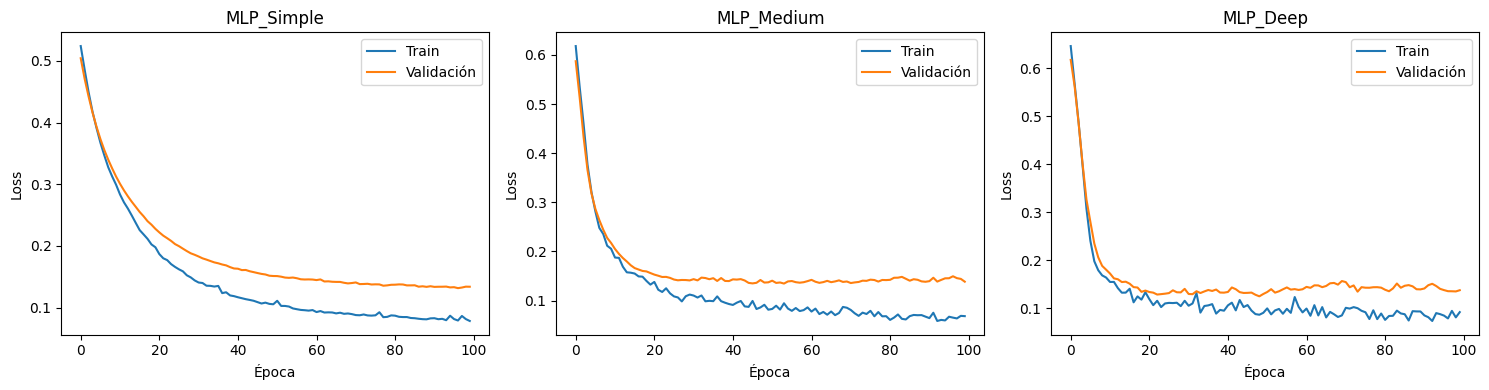

In [149]:
# Comparamos visualmente los 3 modelos entrenados
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
nombres = ['MLP_Simple', 'MLP_Medium', 'MLP_Deep']

for i, (losses, nombre) in enumerate(zip([losses1, losses2, losses3], nombres)):
    axes[i].plot(losses[0], label='Train')
    axes[i].plot(losses[1], label='Validación')
    axes[i].set_title(nombre)
    axes[i].set_xlabel('Época')
    axes[i].set_ylabel('Loss')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [150]:
# Y comparamos los 3 modelos por "accuracy" en validacion
from sklearn.metrics import accuracy_score

def accuracy_validacion(model, valid_loader):
    model.eval()
    y_real, y_pred = [], []
    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            preds = model(X_batch)
            preds = (preds >= 0.5).float()  # umbral 0.5
            y_real.extend(y_batch.numpy())
            y_pred.extend(preds.numpy())
    return accuracy_score(y_real, y_pred)

acc1 = accuracy_validacion(model1, valid_loader)
acc2 = accuracy_validacion(model2, valid_loader)
acc3 = accuracy_validacion(model3, valid_loader)

print(f"MLP_Simple  accuracy: {acc1:.4f}")
print(f"MLP_Medium  accuracy: {acc2:.4f}")
print(f"MLP_Deep    accuracy: {acc3:.4f}")

MLP_Simple  accuracy: 0.9250
MLP_Medium  accuracy: 0.9417
MLP_Deep    accuracy: 0.9333


#### **Justificacion parámetros, entrenamiento y resultado**
- *Épocas: 100* - Para un dataset de 800 datos es suficiente para que el modelo converja
- *Batch size: 32* - Teniendo en cuenta el volumen del dataset, es un balance entre velocidad y aprendizaje
- *Umbral: 0.5* - Estándar para clasificación binaria
- En promedio luego de 10 ejecuciones, **MPL-Deep** resulta exitoso con mayor accuracy en promedio
- *Tipo de entrenamiento: Minibatches* - Se entrena procesando los datos en batches de a 32, lo que facilita actualizar los pesos varias veces por época
- La función creada entrenar está hecha para que los tres modelos puedan usarla, por detrar aplica el mismo entrenamiento a todos.

También notar que en promedio, la diferencia de accuracy no es grande. De hecho, siempre suele ser menos del $5\%$, y todos superan el $90\%$ de accuracy.

### Evaluación del modelo
Evalúe el modelo utilizando métricas adecuadas para este problema de clasificación. Justifique la selección de las métricas utilizadas y discuta los resultados obtenidos. 

Accuracy: 0.9417
F1-Score: 0.6316

Reporte completo:
               precision    recall  f1-score   support

No legendario       0.96      0.97      0.97       110
   Legendario       0.67      0.60      0.63        10

     accuracy                           0.94       120
    macro avg       0.82      0.79      0.80       120
 weighted avg       0.94      0.94      0.94       120



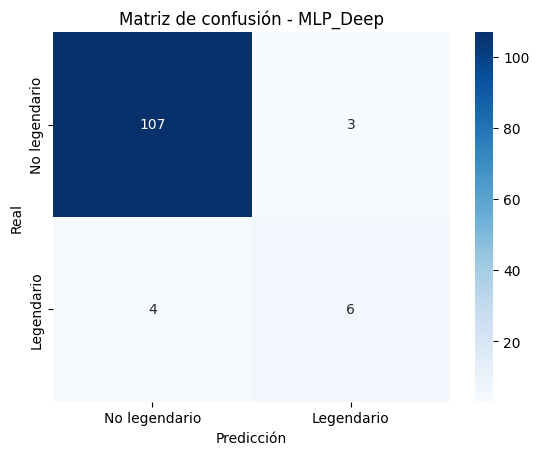

In [151]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# Obtenemos predicciones del modelo ganador (MLP_Deep) sobre el test-set
model3.eval()
y_real, y_pred = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model3(X_batch)
        preds = (preds >= 0.5).float()
        y_real.extend(y_batch.numpy())
        y_pred.extend(preds.numpy())

# Métricas
acc  = accuracy_score(y_real, y_pred)
f1   = f1_score(y_real, y_pred)
print(f"Accuracy: {acc:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nReporte completo:")
print(classification_report(y_real, y_pred, target_names=['No legendario', 'Legendario']))

# Matriz de confusión
cm = confusion_matrix(y_real, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No legendario', 'Legendario'],
            yticklabels=['No legendario', 'Legendario'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión - MLP_Deep')
plt.show()

Si bien total puede sonar redundante, al añadirlo mejoró directamente el F1-Score de la clase legendaria de 0.63 a 0.73 y el recall de 0.6 a 0.8. Osea la red si aprovecha esta feature a su favor.

### Preguntas finales
1. Sobre la matriz de confusión, interprete los resultados obtenidos. Con sus palabras defina que significa cada tipo de error. ¿Elegiría a Pokémon ubicados en FP o FN para su equipo?
2. Busque un caso mal clasificado por el modelo, e interprete por qué cree que el modelo se equivocó en ese caso.
3. ¿Cúal fue el mayor desafío que enfrentó al realizar esta tarea? ¿Cómo lo solucionó?



### IA Generativa

Con el fin de ocupar IA Generativa de manera responsable, se les pide que respondan a las siguientes preguntas:
1. ¿Utilizó alguna herramienta de IA Generativa para realizar esta tarea? En caso afirmativo, indique cuál o cuáles herramientas utilizó.
2. ¿En qué parte o partes de la tarea utilizó estas herramientas?